# **Portfolio Exam 2**


# **Sensor Fusion Particle Filter**

## Task P2.1

 Realize an implementation of the Particle Filter in a programming language of your choice for a
 simulation of the ball-throwing example from the lecture slides. The task of your Particle Filter is
 to estimate the positions and velocity vectors of n ≥ 1 balls ying simultaneously only from the
 observed erroneous positions over time.


*   Simulate the trajectory of n balls with the parameters launch position (x,y) (the imaginary
 ground is at y = 0), launch speed and launch angle/launch direction of each ball.
 The inital positions and ying directions of the balls are unknown to your estimation. You can
 only assume that the ball starts within a rather large range of, for example, 50 × 50 meters.
*   Simulate the observations of the ball positions (x,y). The estimated ball positions shall be
 subject to high uncertainty and it shall be possible to parameterize this uncertainty. In addition, the time span between two observations shall be variable and the observations shall be
 able to drop out completely over a certain period of time. It is necessary that the positions
 of the ball is also estimated during the time of the sensor failure.



*   How to deal with more than one ball ying at the same time? How do you de ne your state?
 Think intensively about what the transition model and the evaluation model should look like
 in the case of n balls.
 How do you estimate n positions from the sensor fusion density? If the density of the ball
 positions is multimodal, select a suitable method that can determine the positions of the balls.
*   You are not able to distinguish between the balls. They are indistinguishable from an obser
vational point of view.


*   
The starting position and other starting parameters are just as unknown and cannot be
 speci ed more precisely. You should handle both the case where the starting positions and
 directions of the balls are very similar and the case where the positions and directions are
 clearly different in one common approach.







# Physics Simulation

Running physics simulation
Simulation complete. Generated 102 time steps of data.
Plotting simulated trajectories


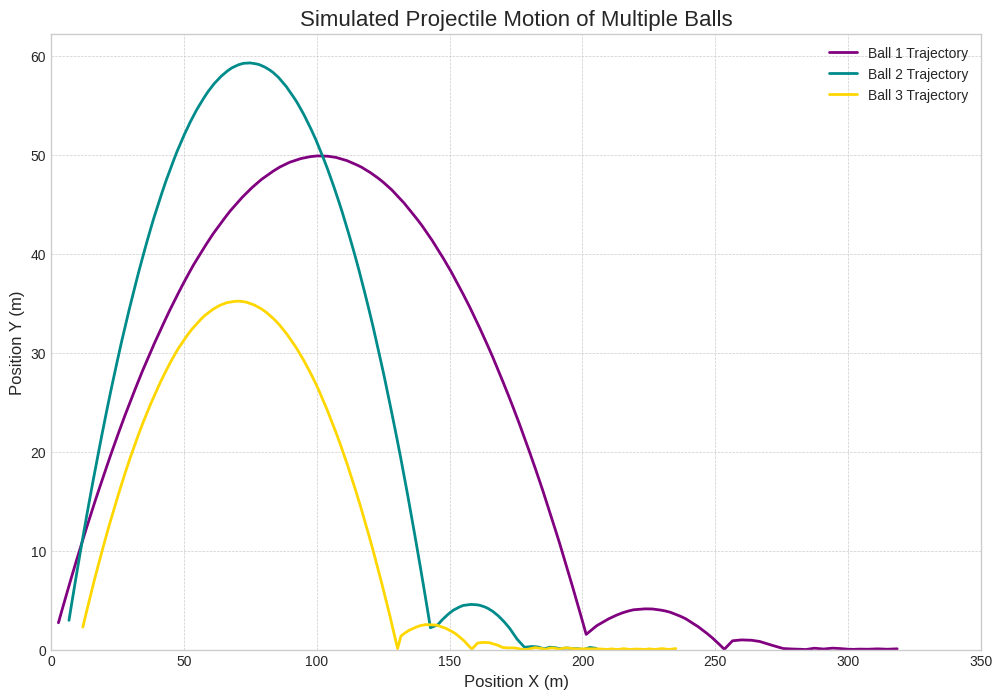

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Dict, Optional
import time
from scipy.stats import multivariate_normal
from sklearn.cluster import DBSCAN
from itertools import permutations

# Set random seed for reproducibility
np.random.seed(42)

#  Physics Simulation

def simulate_multiple_balls(n_balls: int, launch_params: List[Dict],
                            dt: float, total_time: float,
                            observation_noise_cov: np.ndarray,
                            dropout_prob: float = 0.15,
                            variable_dt: bool = False):
  # n_balls = number of balls
  # launch_params = initial launch conditions (position, speed, angle)
  # dt = simulation time step
  # total_time = total simulation duration
  # observation_noise_cov =  2x2 covariance matrix for adding Gaussian noise to (x, y) positions
  # dropout_prob = Probability of dropping observations (simulates missing sensor data)
  # variable_dt = Adds randomness to the time step at each iteration

    balls = []
    for params in launch_params:
        ball = {
            'position': np.array(params['launch_position'], dtype=float),
            'velocity': params['launch_speed'] * np.array([
                np.cos(np.deg2rad(params['launch_angle'])),
                np.sin(np.deg2rad(params['launch_angle']))
            ], dtype=float),
            'gravity': np.array([0, -9.81], dtype=float)
        }
        balls.append(ball)

    # Initialize dictionary to store true trajectory of each ball
    # Each key (ball index) maps to a list of state vectors over time
    true_trajectories = {i: [] for i in range(n_balls)}
    observations_list = []
    time_steps = []
    dt_list = []

    current_time = 0
    while current_time < total_time:
        actual_dt = dt * np.random.uniform(0.5, 1.5) if variable_dt else dt

        for i, ball in enumerate(balls):
            # Update velocity using gravity: v = v + a * dt
            ball['velocity'] += ball['gravity'] * actual_dt
            # Update position using velocity: x = x + v * dt
            ball['position'] += ball['velocity'] * actual_dt
            # Checking if the ball hits the ground (y < 0)
            if ball['position'][1] < 0:
                # Reflect the position to simulate bounce
                ball['position'][1] = -ball['position'][1]
                # Reverse and reduce vertical velocity (damping factor 0.2)
                ball['velocity'][1] *= -0.2

            full_state = np.concatenate([ball['position'].copy(), ball['velocity'].copy()])
            true_trajectories[i].append(full_state)

        # With probability (1 - dropout_prob), generate noisy observations
        if np.random.random() > dropout_prob:
            observations = []
            for ball in balls:
                # Only observe the ball if it is above the ground
                if ball['position'][1] > 0:
                    # Add Gaussian noise to the true position using the given covariance
                    noisy_obs = ball['position'] + np.random.multivariate_normal(
                        [0, 0], observation_noise_cov)
                    observations.append(noisy_obs)
            observations_list.append(observations)
        else:
            # Simulate dropout: no observation recorded at this time step
            observations_list.append(None)

        time_steps.append(current_time)
        dt_list.append(actual_dt)
        current_time += actual_dt

    return true_trajectories, observations_list, time_steps, dt_list

#  Simulation Setup
N_BALLS = 3
DT = 0.1
TOTAL_TIME = 10.0
# These initial parameters define how each ball is launched. By varying speeds and angles, we get different trajectories
LAUNCH_PARAMS = [
    {'launch_position': [0, 0], 'launch_speed': 45, 'launch_angle': 45},
    {'launch_position': [5, 0], 'launch_speed': 40, 'launch_angle': 60},
    {'launch_position': [10, 0], 'launch_speed': 35, 'launch_angle': 50},
]
OBSERVATION_NOISE_COV = np.diag([2.0, 2.0]) #simulates real-world sensor inaccuracies
TRANSITION_COV = np.diag([0.2, 0.2, 0.2, 0.2])

print("Running physics simulation")
# Calling simulate_multiple_balls function with 15% prob of observation dropout
true_trajectories, observations_list, time_steps, dt_list = simulate_multiple_balls(
    N_BALLS, LAUNCH_PARAMS, DT, TOTAL_TIME,
    OBSERVATION_NOISE_COV, dropout_prob=0.15, variable_dt=True
)
print(f"Simulation complete. Generated {len(time_steps)} time steps of data.") # to know how many simulation steps were generated
print("Plotting simulated trajectories")
plt.figure(figsize=(12, 8))
plt.style.use('seaborn-v0_8-whitegrid')

# Define colors for the balls - Added more colors to match N_BALLS
colors = ['purple', 'darkcyan', 'gold']

# Plot the trajectory for each ball
for i in range(N_BALLS):
    # Extract the x and y coordinates from the trajectory data
    x_coords = [pos[0] for pos in true_trajectories[i]]
    y_coords = [pos[1] for pos in true_trajectories[i]]
    plt.plot(x_coords, y_coords, '-', color=colors[i], label=f'Ball {i+1} Trajectory', linewidth=2)

# Add titles and labels for clarity
plt.title('Simulated Projectile Motion of Multiple Balls', fontsize=16)
plt.xlabel('Position X (m)', fontsize=12)
plt.ylabel('Position Y (m)', fontsize=12)

# Set the axis limits. This will now work as expected
plt.xlim(0, 350)
plt.ylim(bottom=0)

# Add a legend to identify each ball
plt.legend()

# Add a grid for better readability
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Display the plot
plt.show()

# **Particle filter**

In [ ]:
#Particle filte
class MultiBallParticleFilter:
    def __init__(self, n_balls: int, num_particles: int = 3000,
                 init_range: float = 50.0, gravity: float = -9.81,
                 dt: float = 0.1):
        self.n_balls = n_balls
        self.num_particles = num_particles
        self.gravity = gravity
        self.dt = dt
        self.init_range = init_range
        self.initialize_particles()

    def initialize_particles(self):
        self.particles = np.zeros((self.num_particles, self.n_balls, 4))
        # Looping through each particle and each ball to initialize their individual state
        for i in range(self.num_particles):
            for j in range(self.n_balls):
                # Initializing position randomly
                self.particles[i, j, 0] = np.random.uniform(-self.init_range/2, self.init_range/2)
                self.particles[i, j, 1] = np.random.uniform(0, self.init_range/2) # Always above ground
                # Randomly sample launch speed and angle to define initial velocity
                speed = np.random.uniform(20, 50)
                angle = np.random.uniform(30, 80)
                self.particles[i, j, 2] = speed * np.cos(np.deg2rad(angle)) # vx = speed × cos(angle)
                self.particles[i, j, 3] = speed * np.sin(np.deg2rad(angle)) #vy = speed × sin(angle)
        # Assign uniform weights to all particles initially (equal probability)
        self.weights = np.ones(self.num_particles) / self.num_particles

    def predict_particles(self, transition_cov, dt: Optional[float] = None):
        # Use the specified dt if given, otherwise use default dt from initialization
        current_dt = dt if dt is not None else self.dt
        # Iterate through each particle and each ball to update states
        for i in range(self.num_particles):
            for j in range(self.n_balls):
                # Sample 4D Gaussian noise for [x, y, vx, vy] with given covariance
                noise = np.random.multivariate_normal([0, 0, 0, 0], transition_cov)
                # equations apply Newtonian motion under constant velocity, this predicts where the ball goes next
                self.particles[i, j, 0] += self.particles[i, j, 2] * current_dt + noise[0]
                self.particles[i, j, 1] += self.particles[i, j, 3] * current_dt + noise[1]
                # x-velocity may drift due to air or bounce friction so vx remains constant
                self.particles[i, j, 2] += noise[2]
                # y-velocity changes due to gravity
                self.particles[i, j, 3] += self.gravity * current_dt + noise[3]
                # Handling ground collision:
                if self.particles[i, j, 1] < 0:
                    # Reflect position back above ground
                    self.particles[i, j, 1] = -self.particles[i, j, 1]
                    # simulate bounce energy loss
                    self.particles[i, j, 3] *= -0.2

    def update_weights(self, observations, observation_cov, dropout=False):
        if dropout or observations is None or len(observations) == 0:
            return
        #new weight = (old weight * likelihood)
        #increases weights for particles that are more consistent with current sensor readings
        for i in range(self.num_particles):
            likelihood = self._compute_assignment_likelihood(
                self.particles[i], observations, observation_cov)
            self.weights[i] *= likelihood
        #This ensures no weight is exactly zero
        self.weights += 1.e-300
        # Normalize weights so they sum to 1,  which is required for effective sampling and computing metrics like Neff
        self.weights /= np.sum(self.weights)

    #Each observation may correspond to any ball, so we must test all possible assignments.
    def _compute_assignment_likelihood(self, particle_balls, observations, observation_cov):
        n_obs = len(observations)
        if n_obs > self.n_balls: return 0.01
        if n_obs == 0: return 1.0
        best_likelihood = 0.0
        # Trying all possible ways to assign observations to different balls (n_obs out of n_balls)
        for perm in permutations(range(self.n_balls), n_obs):
            likelihood = 1.0
            # For each observation-ball pairing in this permutation:
            for obs_idx, ball_idx in enumerate(perm):
                diff = observations[obs_idx] - particle_balls[ball_idx, :2] #difference between observed and predicted position
                likelihood *= multivariate_normal.pdf(diff, mean=np.zeros(2), cov=observation_cov)
            likelihood *= (0.1 ** (self.n_balls - n_obs)) # Penalize missing observations
            best_likelihood = max(best_likelihood, likelihood)
        return best_likelihood

    #Resampling focuses computational effort on more likely hypotheses and avoids weight degeneracy
    def resample_particles(self):
        #Neff is a common measure in particle filtering to assess how well-distributed the weights are
        neff = 1. / np.sum(np.square(self.weights))
        # Replace current particles with resampled ones, and reset weights to uniform
        if neff < self.num_particles / 2:
            indices = np.random.choice(range(self.num_particles), self.num_particles, p=self.weights)
            self.particles = self.particles[indices]
            self.weights = np.ones(self.num_particles) / self.num_particles

    # This method extracts the best estimate of the system state from the weighted set of particles
    def estimate_states(self):
        all_positions, all_velocities, all_weights = [], [], []
        for i in range(self.num_particles):
            if self.weights[i] > (1.0 / (self.num_particles * 10)):   #Filters out noisy or poorly matched particles
                # This transforms the 3D array of particles into a flat list of state samples, suitable for clustering
                for j in range(self.n_balls):
                    all_positions.append(self.particles[i, j, :2])
                    all_velocities.append(self.particles[i, j, 2:])
                    all_weights.append(self.weights[i])
        if not all_positions:
            return [np.average(self.particles, weights=self.weights, axis=0)[j] for j in range(self.n_balls)]

        all_positions = np.array(all_positions)
        # DBSCAN is robust to noise and does not require specifying the number of clusters
        # useful when some balls may be missing in observations
        clustering = DBSCAN(eps=3.5, min_samples=15).fit(all_positions, sample_weight=all_weights)
        estimated_states = []
        unique_labels = set(clustering.labels_)
        unique_labels.discard(-1)
        for label in unique_labels:
            mask = clustering.labels_ == label
            total_weight = np.sum(all_weights[mask])
            # gives us one state estimate per detected ball, inferred from clusters of particles
            if total_weight > 0:
                avg_pos = np.average(all_positions[mask], weights=all_weights[mask], axis=0)
                avg_vel = np.average(np.array(all_velocities)[mask], weights=all_weights[mask], axis=0)
                estimated_states.append(np.concatenate([avg_pos, avg_vel]))

        # If fewer clusters were found than the number of balls:
        # Fill in the missing states with weighted mean from all particles
        while len(estimated_states) < self.n_balls:
            mean_state = np.average(self.particles, weights=self.weights, axis=0)
            estimated_states.append(mean_state[len(estimated_states)])
        return estimated_states[:self.n_balls]

#  Particle Filter Main Loop
start_time = time.time()
print("\nInitializing Particle Filter")
pf = MultiBallParticleFilter(n_balls=N_BALLS, num_particles=3000, init_range=50.0, dt=DT)
estimated_trajectories = {i: [] for i in range(N_BALLS)}
print("Running Particle Filter tracking")

for step, (obs, t, current_dt) in enumerate(zip(observations_list, time_steps, dt_list)):
    #1.Predict
    pf.predict_particles(TRANSITION_COV, dt=current_dt)

     #2.Update
    dropout = (obs is None)
    pf.update_weights(obs, OBSERVATION_NOISE_COV, dropout=dropout)

    #3.Resample
    pf.resample_particles()

    #4.Estimate
    estimates = pf.estimate_states()

    #Store estimates using a simple distance based assignment for plotting
    if estimates:
        unassigned_estimates = list(range(len(estimates)))
        true_positions_at_t = [true_trajectories[b][step][:2] for b in range(N_BALLS)]
        assignments = {}
        # For each true ball, find the closest estimated ball (Euclidean distance)
        for true_idx, true_pos in enumerate(true_positions_at_t):
            best_dist, best_est_idx = float('inf'), -1
            # Track the estimate with the minimum distance to the true position
            for est_idx in unassigned_estimates:
                dist = np.linalg.norm(estimates[est_idx][:2] - true_pos)
                if dist < best_dist:
                    best_dist, best_est_idx = dist, est_idx
            # Assign the best match and mark it as used
            if best_est_idx != -1:
                assignments[true_idx] = best_est_idx
                unassigned_estimates.remove(best_est_idx)
        # Store the estimated state of each assigned ball
        for i in range(N_BALLS):
            if i in assignments:
                # Store the full estimated state (x, y, vx, vy)
                estimated_trajectories[i].append(estimates[assignments[i]])
   #  The print statement now checks the 'dropout' variable
        dropout = (obs is None)
        dropout_status = " (DROPOUT)" if dropout else ""
        print(f"   Step {step}/{len(time_steps)}: t={t:.2f}s{dropout_status}")

print("Tracking complete")
end_time = time.time()


Initializing Particle Filter
Running Particle Filter tracking
   Step 0/102: t=0.00s
   Step 1/102: t=0.09s
   Step 2/102: t=0.14s
   Step 3/102: t=0.23s
   Step 4/102: t=0.30s
   Step 5/102: t=0.42s
   Step 6/102: t=0.53s
   Step 7/102: t=0.66s
   Step 8/102: t=0.71s (DROPOUT)
   Step 9/102: t=0.79s
   Step 10/102: t=0.87s
   Step 11/102: t=1.00s
   Step 12/102: t=1.08s
   Step 13/102: t=1.22s
   Step 14/102: t=1.35s
   Step 15/102: t=1.41s
   Step 16/102: t=1.51s
   Step 17/102: t=1.56s
   Step 18/102: t=1.64s
   Step 19/102: t=1.69s (DROPOUT)
   Step 20/102: t=1.83s (DROPOUT)
   Step 21/102: t=1.92s
   Step 22/102: t=2.06s
   Step 23/102: t=2.12s
   Step 24/102: t=2.26s
   Step 25/102: t=2.37s
   Step 26/102: t=2.49s
   Step 27/102: t=2.63s (DROPOUT)
   Step 28/102: t=2.71s
   Step 29/102: t=2.82s
   Step 30/102: t=2.96s
   Step 31/102: t=3.07s
   Step 32/102: t=3.15s
   Step 33/102: t=3.27s
   Step 34/102: t=3.37s
   Step 35/102: t=3.50s
   Step 36/102: t=3.62s
   Step 37/102: t=3

# **Plotting the Results**


 Error Analysis
Ball 1 RMSE: 2.7579
Ball 2 RMSE: 3.6966
Ball 3 RMSE: 3.8318

Overall RMSE: 3.4619

 Total computation time: 761.37 seconds

 Plotting Trajectory Summary 


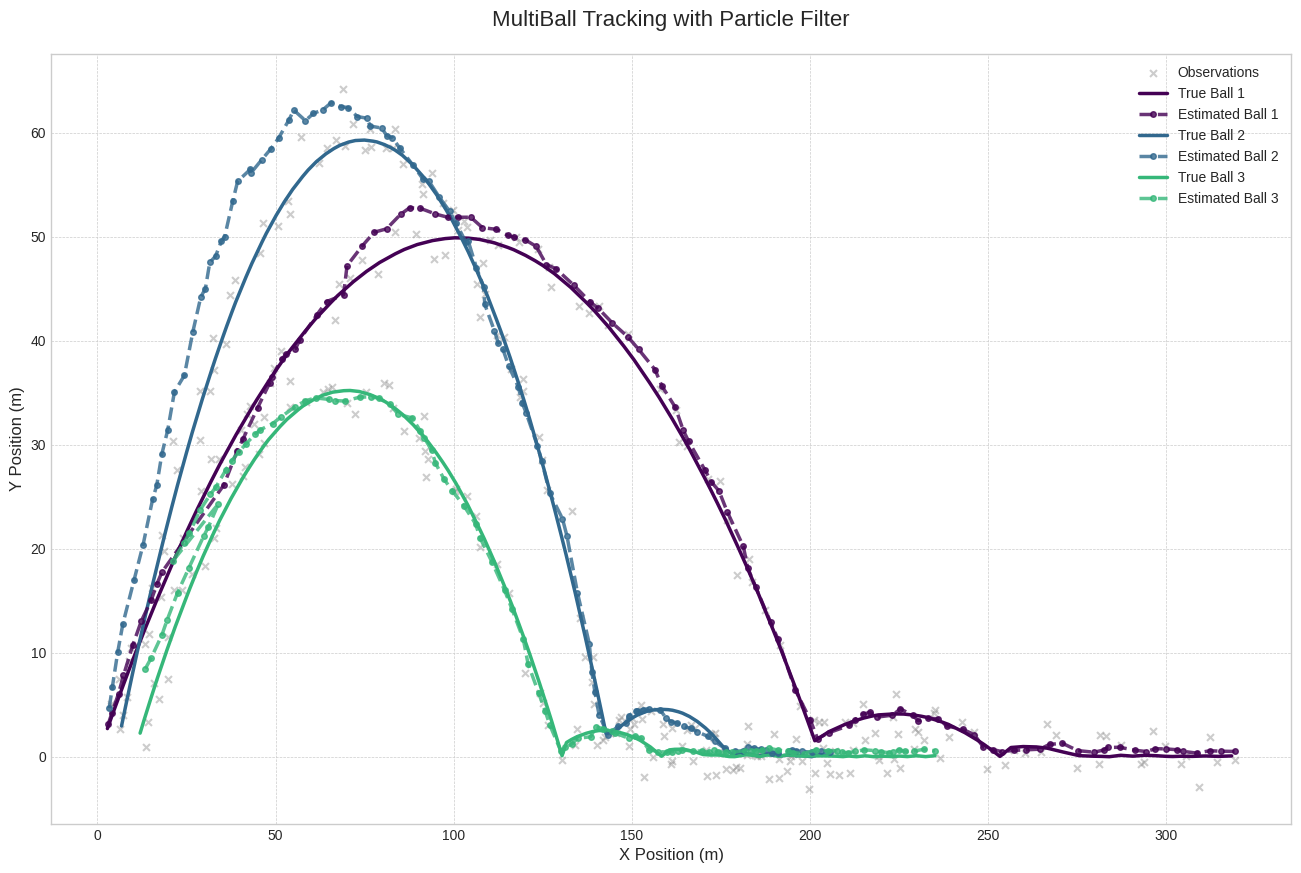


 Plotting Dropout vs Tracking Error Analysis 


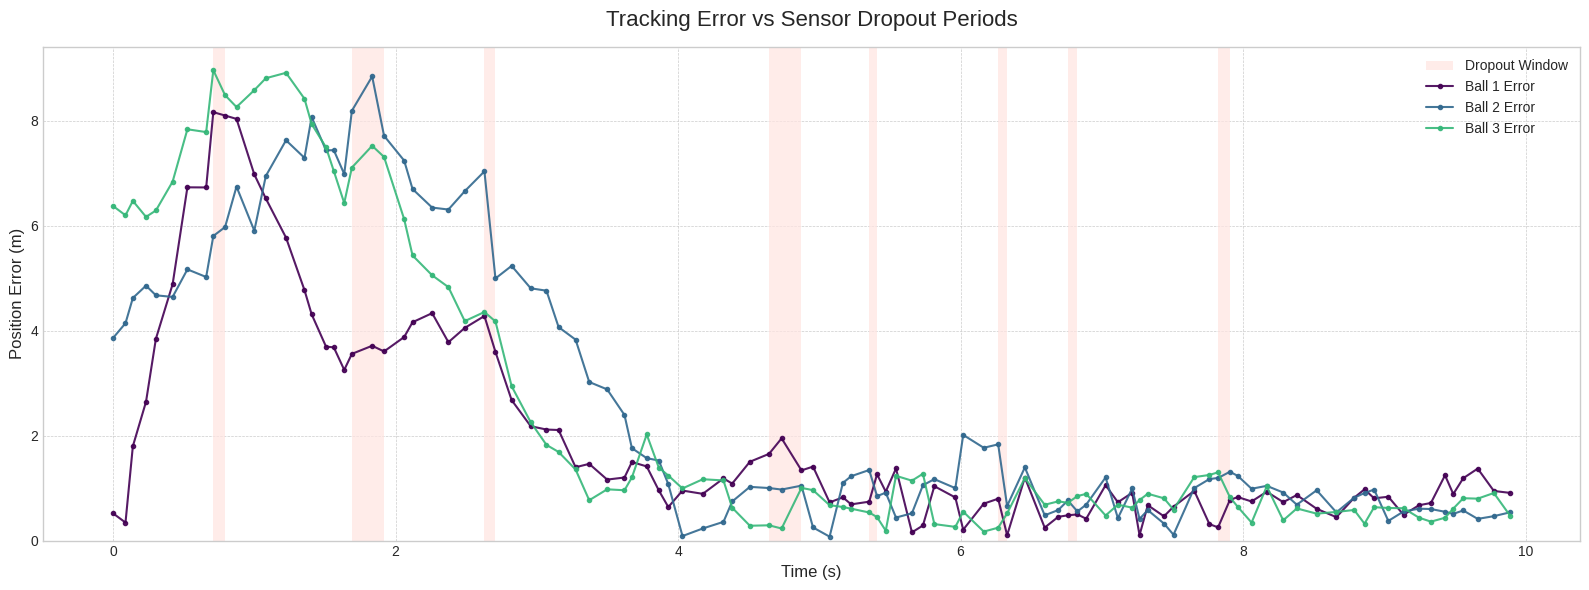


 Plotting Velocity vs Distance Analysis 


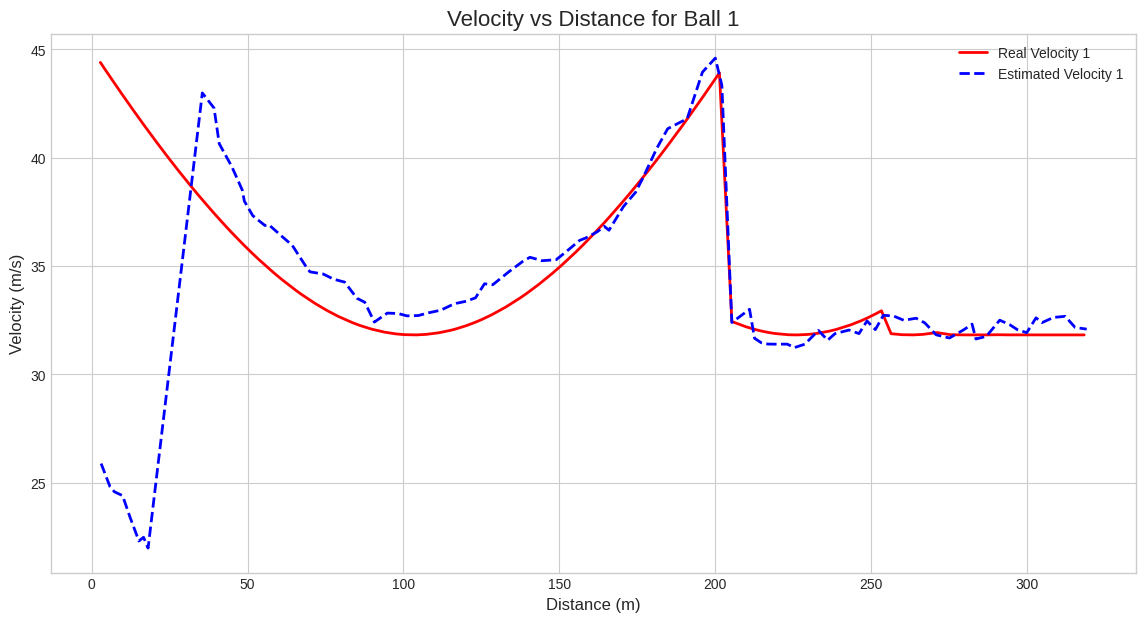

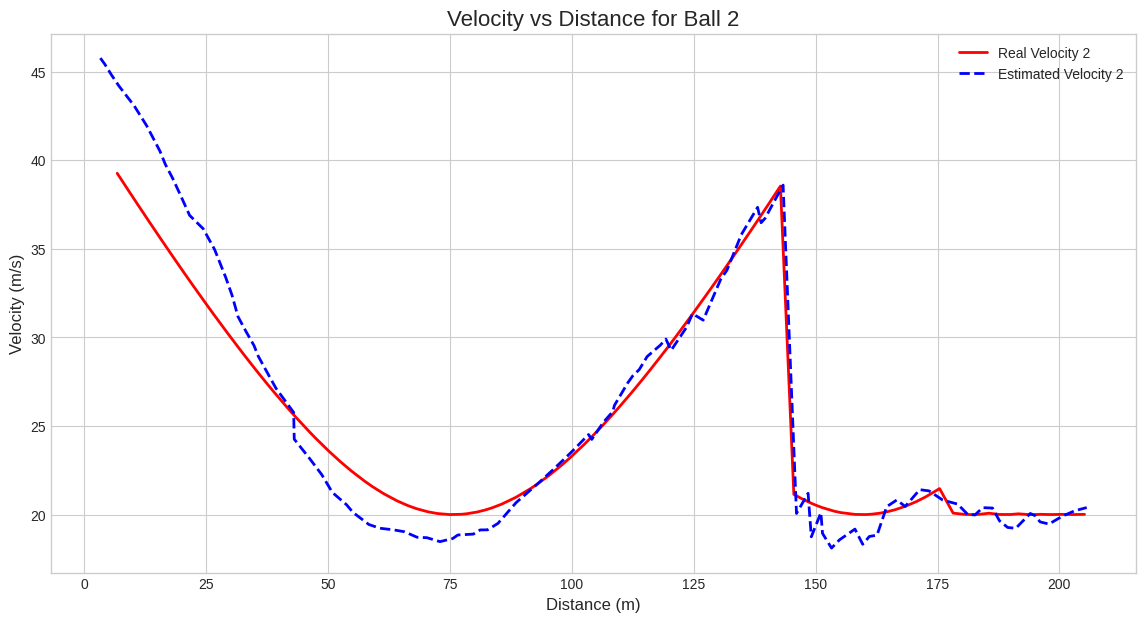

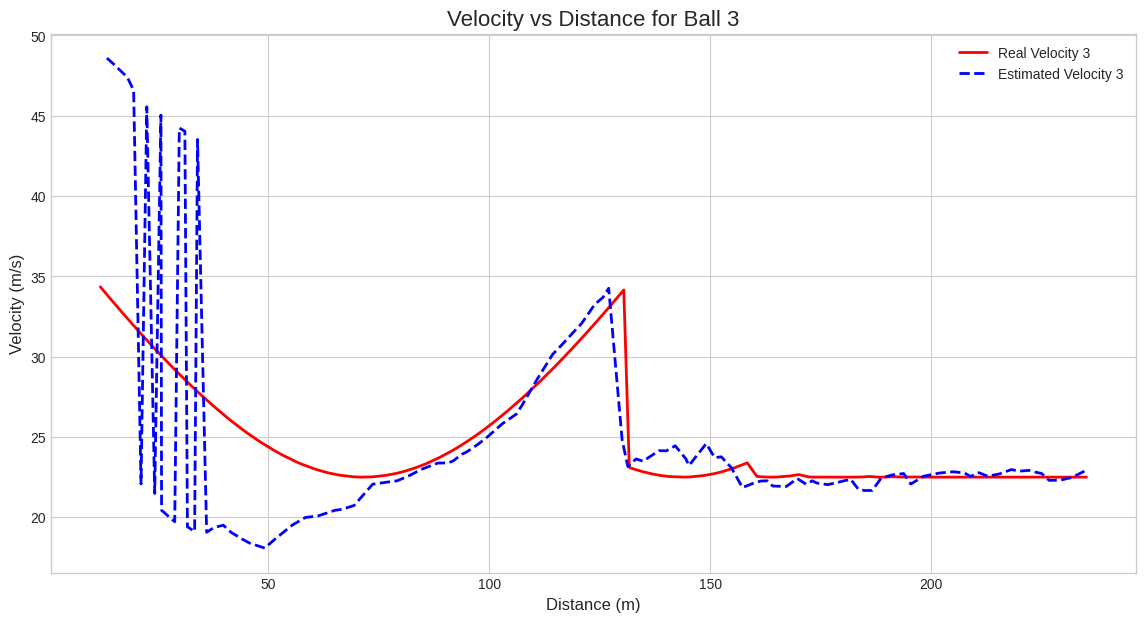

In [ ]:
#To visualize the actual vs. estimated 2D trajectories of each ball across time, alongside noisy observations
def plot_trajectories(true_trajectories, estimated_trajectories, observations_list, n_balls):
    plt.figure(figsize=(16, 10))
    colors = plt.colormaps.get_cmap('viridis')
    all_obs_x = [obs[0] for obs_list in observations_list if obs_list for obs in obs_list]
    all_obs_y = [obs[1] for obs_list in observations_list if obs_list for obs in obs_list]
    plt.scatter(all_obs_x, all_obs_y, color='gray', alpha=0.4, s=25, label='Observations', marker='x', zorder=1) # To understand how noisy and sparse the sensor readings are

    for i in range(n_balls):
        color = colors(i / n_balls) # unique color to each ball
        true_pos = np.array(true_trajectories[i])[:, :2]
        plt.plot(true_pos[:, 0], true_pos[:, 1], color=color, linewidth=2.5, label=f'True Ball {i+1}', zorder=2) #Plot the true trajectory using solid lines
        #predicted trajectory using dashed lines with markers
        if estimated_trajectories[i]:
            est_pos = np.array(estimated_trajectories[i])[:, :2]
            plt.plot(est_pos[:, 0], est_pos[:, 1], color=color, linewidth=2.5, linestyle='--', marker='o', markersize=4, alpha=0.8, label=f'Estimated Ball {i+1}', zorder=3)

    plt.xlabel('X Position (m)', fontsize=12)
    plt.ylabel('Y Position (m)', fontsize=12)
    plt.title('MultiBall Tracking with Particle Filter', fontsize=16, pad=20)
    plt.legend()
    plt.grid(True, which='both', linestyle='--', linewidth=0.5)
    plt.show()

#To show how accurate tracking is across time, and how sensor dropouts affect the error
def plot_dropout_error_analysis(true_trajectories, estimated_trajectories,
                                observations_list, n_balls, time_steps, dt_list):
    fig, ax = plt.subplots(figsize=(16, 6))
    colors = plt.colormaps.get_cmap('viridis')
    dropout_legend_added = False
    # Highlights time windows where observations were missing (dropouts) using a red translucent background
    for i, (t, obs) in enumerate(zip(time_steps, observations_list)):
        if obs is None:
            span_width = dt_list[i]
            label = 'Dropout Window' if not dropout_legend_added else ''
            ax.axvspan(t, t + span_width, color='mistyrose', alpha=0.7, lw=0, label=label)
            dropout_legend_added = True
    #For each ball, compute the Euclidean error between estimated and true positions
    for i in range(n_balls):
        color = colors(i / n_balls)
        num_estimates = len(estimated_trajectories[i])
        if num_estimates > 0:
            true_pos = np.array([true_trajectories[i][j][:2] for j in range(num_estimates)])
            est_pos = np.array(estimated_trajectories[i])[:, :2]
            errors = np.linalg.norm(true_pos - est_pos, axis=1)
            time_points_with_estimates = [time_steps[j] for j in range(num_estimates)]
            ax.plot(time_points_with_estimates, errors, color=color, label=f'Ball {i+1} Error', alpha=0.9, marker='.', markersize=6, linestyle='-')

    ax.set_xlabel('Time (s)', fontsize=12)
    ax.set_ylabel('Position Error (m)', fontsize=12)
    ax.set_title('Tracking Error vs Sensor Dropout Periods', fontsize=16, pad=15)
    ax.legend()
    ax.grid(True, which='both', linestyle='--', linewidth=0.5)
    ax.set_ylim(bottom=0)
    plt.tight_layout()
    plt.show()

# To analyze how accurately the velocity is tracked as the ball travels through space
def plot_velocity_vs_distance(true_trajectories, estimated_trajectories, n_balls):
    print("\n Plotting Velocity vs Distance Analysis ")
    for i in range(n_balls):
        plt.figure(figsize=(14, 7))

        # True Data
        true_states = np.array(true_trajectories[i])
        true_dist = true_states[:, 0]  # x-position is the distance
        true_vel = np.linalg.norm(true_states[:, 2:], axis=1) # Magnitude of (vx, vy)

        # Sort by distance to ensure the line plots correctly from left to right
        sort_indices_true = np.argsort(true_dist)
        plt.plot(true_dist[sort_indices_true], true_vel[sort_indices_true], 'r-', label=f'Real Velocity {i+1}', linewidth=2)

        # Estimated Data
        if estimated_trajectories[i]:
            est_states = np.array(estimated_trajectories[i])
            est_dist = est_states[:, 0]
            est_vel = np.linalg.norm(est_states[:, 2:], axis=1)

            # Sort by distance
            sort_indices_est = np.argsort(est_dist)
            plt.plot(est_dist[sort_indices_est], est_vel[sort_indices_est], 'b--', label=f'Estimated Velocity {i+1}', linewidth=2)

        plt.title(f'Velocity vs Distance for Ball {i+1}', fontsize=16)
        plt.xlabel('Distance (m)', fontsize=12)
        plt.ylabel('Velocity (m/s)', fontsize=12)
        plt.legend()
        plt.grid(True)
        plt.show()

# Error Analysis
print("\n Error Analysis")
total_errors = []
for i in range(N_BALLS):
    num_estimates = len(estimated_trajectories[i])
    #Only analyze balls that have predictions
    if num_estimates > 0:
        true_pos = np.array([true_trajectories[i][j][:2] for j in range(num_estimates)])
        est_pos = np.array(estimated_trajectories[i])[:, :2]
        errors = np.linalg.norm(true_pos - est_pos, axis=1)
        #Extract only (x, y) positions and compute Euclidean distance between the true and estimated positions at each time step
        total_errors.extend(errors)
        rmse = np.sqrt(np.mean(errors**2))  #Calculate Root Mean Squared Error (RMSE) for this ball and display it
        print(f"Ball {i+1} RMSE: {rmse:.4f}")

if total_errors:
    overall_rmse = np.sqrt(np.mean(np.square(total_errors)))
    print(f"\nOverall RMSE: {overall_rmse:.4f}")
# Aggregates errors across all balls to give a single score representing total tracking performance
print(f"\n Total computation time: {end_time - start_time:.2f} seconds")

#Call the plotting functions
print("\n Plotting Trajectory Summary ")
plot_trajectories(true_trajectories, estimated_trajectories, observations_list, N_BALLS)

print("\n Plotting Dropout vs Tracking Error Analysis ")
plot_dropout_error_analysis(
    true_trajectories, estimated_trajectories,
    observations_list, N_BALLS, time_steps, dt_list
)

# Call the function to generate the requested plots
plot_velocity_vs_distance(true_trajectories, estimated_trajectories, N_BALLS)


# **Graphs (results)**



*   Multi Ball Tracking with Particle Filter This plot shows the ground truth trajectories (solid lines), the noisy sensor observations (gray 'x' markers), and the particle filter's final estimated trajectories (dashed lines with circles). It provides a high-level visual assessment of the tracking performance.

*   Tracking Error vs. Sensor Dropout This graph plots the position error (the distance between the true and estimated position) for each ball over time. The red shaded areas indicate "Dropout Windows" where the sensor provided no data. This visualization clearly shows how the filter's uncertainty and error grow during dropouts and then quickly recover once new data becomes available.


*  Velocity vs. Distance Analysis This set of plots (one for each ball) compares the true velocity magnitude against the filter's estimated velocity as a function of horizontal distance traveled. This provides a insight into the filter's ability to accurately estimate not just the position, but also the dynamic state velocity of the objects.





Name: Thota Bhuvana Chandra

**Matriculation Number: 10001026**

**Email: bhuvanachandra.thota@study.thws.de**

Name: Sai Surya Mada

**Matriculation Number:10000982**

**Email: saisurya.mada@study.thws.de**

# ---------------------------The End-----------------------